In [40]:
%reset -f

In [43]:
import pandas as pd

df = pd.read_csv('/content/CHANDON-2.csv')

# View first 5 rows
print(df.head())

       DEPTH         GR      RHO8      NPHI  Lithology       UCS         Sv  \
0  2551.0632  80.562557  2.286077  0.448558  claystone  2.502680  48.220622   
1  2551.2132  80.631205  2.286776  0.451218  claystone  2.485824  48.224000   
2  2551.3632  80.359733  2.288041  0.453442  claystone  2.471894  48.227375   
3  2551.5132  79.718936  2.290157  0.456280  claystone  2.454325  48.230745   
4  2551.6632  78.954521  2.292327  0.458649  claystone  2.439843  48.234114   

        Phyd         PP        RT  
0  25.025930  26.440812 -0.018771  
1  25.027401  26.573145 -0.014484  
2  25.028873  26.683260 -0.012244  
3  25.030344  26.821218 -0.011129  
4  25.031816  26.935705 -0.014214  


In [44]:
# Keep only data up to 3060 m depth
df = df[df['DEPTH'] <= 3060].copy()

# Reset index
df.reset_index(drop=True, inplace=True)

# Check result
print(df[['DEPTH']])

          DEPTH
0     2551.0632
1     2551.2132
2     2551.3632
3     2551.5132
4     2551.6632
...         ...
3388  3059.2632
3389  3059.4132
3390  3059.5632
3391  3059.7132
3392  3059.8632

[3393 rows x 1 columns]


In [45]:
df.columns

Index(['DEPTH', 'GR', 'RHO8', 'NPHI', 'Lithology', 'UCS', 'Sv', 'Phyd', 'PP',
       'RT'],
      dtype='object')

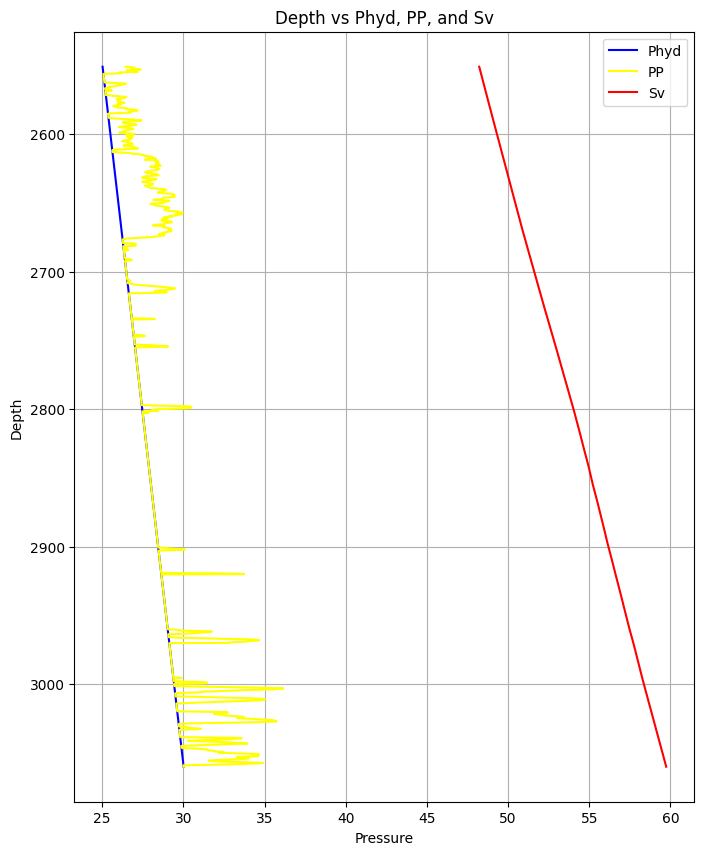

In [46]:
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(8, 10))

# Plot curves
plt.plot(df['Phyd'], df['DEPTH'], color='blue', label='Phyd')
plt.plot(df['PP'], df['DEPTH'], color='yellow', label='PP')
plt.plot(df['Sv'], df['DEPTH'], color='red', label='Sv')

# Reverse depth axis (common in well logs)
plt.gca().invert_yaxis()

# Labels and title
plt.xlabel('Pressure')
plt.ylabel('Depth')
plt.title('Depth vs Phyd, PP, and Sv')

# Legend and grid
plt.legend()
plt.grid(True)

# Show plot
plt.show()

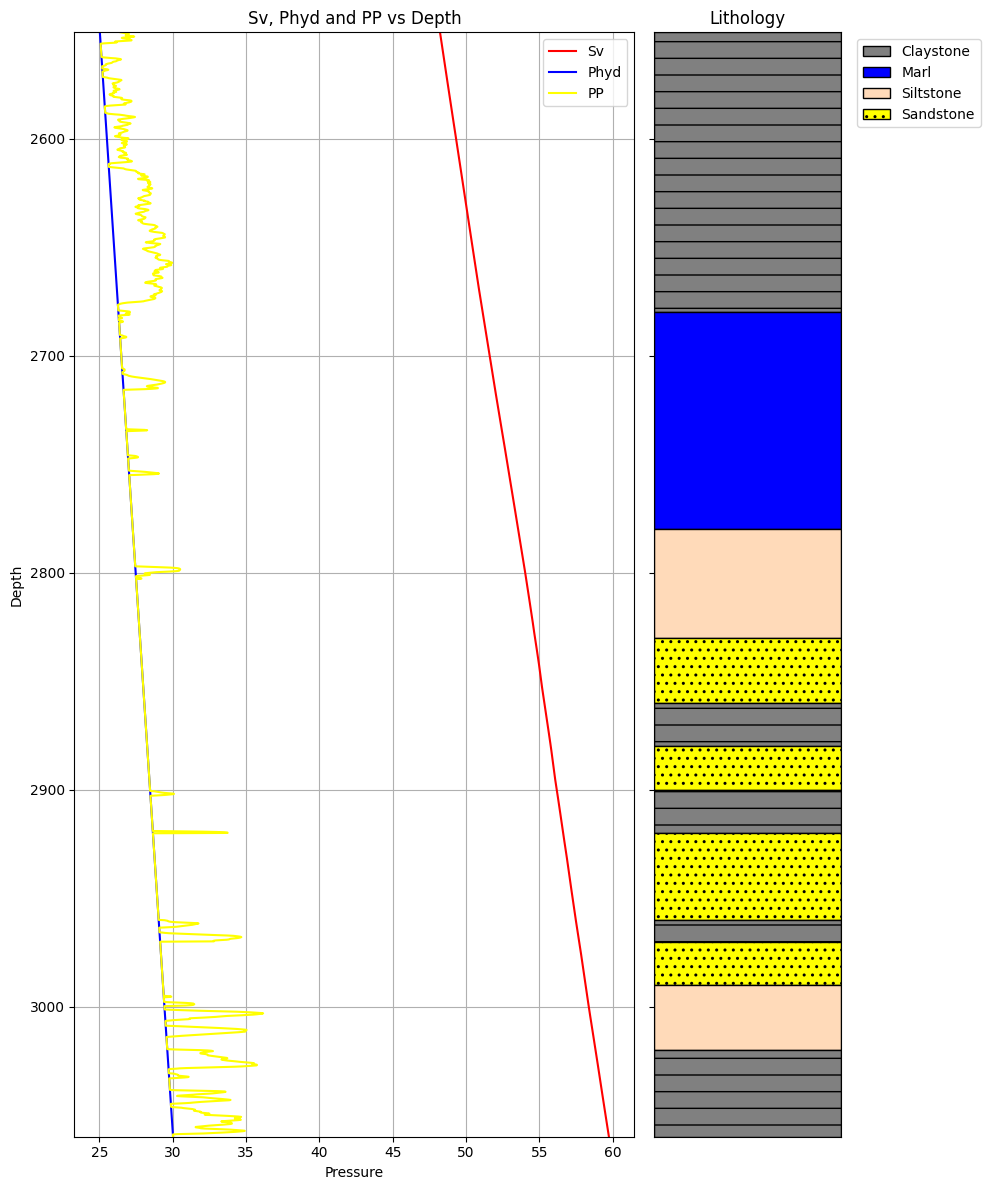

In [47]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch

# Define lithology intervals
start = df['DEPTH'].min()

litho = [
    (start, 2680, 'claystone', 'grey', '-'),
    (2680, 2780, 'marl', 'blue', ''),
    (2780, 2830, 'siltstone', 'peachpuff', ''),
    (2830, 2860, 'fine sandstone', 'yellow', '..'),
    (2860, 2880, 'claystone', 'grey', '-'),
    (2880, 2900, 'fine sandstone', 'yellow', '..'),
    (2900, 2920, 'claystone', 'grey', '-'),
    (2920, 2960, 'sandstone', 'yellow', '..'),
    (2960, 2970, 'claystone', 'grey', '-'),
    (2970, 2990, 'fine sandstone', 'yellow', '..'),
    (2990, 3020, 'siltstone', 'peachpuff', ''),
    (3020, 3060, 'claystone', 'grey', '-'),

]

# Create figure
fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 12),
    gridspec_kw={'width_ratios': [3, 1]},
    sharey=True
)

# ---------------- Pressure Curves ----------------
axes[0].plot(df['Sv'], df['DEPTH'], color='red', label='Sv')
axes[0].plot(df['Phyd'], df['DEPTH'], color='blue', label='Phyd')
axes[0].plot(df['PP'], df['DEPTH'], color='yellow', label='PP')

# Depth increasing downward
axes[0].invert_yaxis()

axes[0].set_xlabel('Pressure')
axes[0].set_ylabel('Depth')
axes[0].set_title('Sv, Phyd and PP vs Depth')
axes[0].legend()
axes[0].grid(True)

# ---------------- Lithology Track ----------------
for top, bottom, lith, color, hatch in litho:
    rect = Rectangle(
        (0, top),      # x, y
        1,             # width
        bottom - top,  # height
        facecolor=color,
        hatch=hatch,
        edgecolor='black'
    )
    axes[1].add_patch(rect)

# Match depth orientation
axes[1].invert_yaxis()

# Set limits
axes[1].set_xlim(0, 1)
axes[1].set_ylim(df['DEPTH'].max(), df['DEPTH'].min())

axes[1].set_xticks([])
axes[1].set_title('Lithology')

# Legend
legend_patches = [
    Patch(facecolor='grey', edgecolor='black', hatch='-', label='Claystone'),
    Patch(facecolor='blue', edgecolor='black', label='Marl'),
    Patch(facecolor='peachpuff', edgecolor='black', label='Siltstone'),
    Patch(facecolor='yellow', edgecolor='black', hatch='..', label='Sandstone')
]

axes[1].legend(
    handles=legend_patches,
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

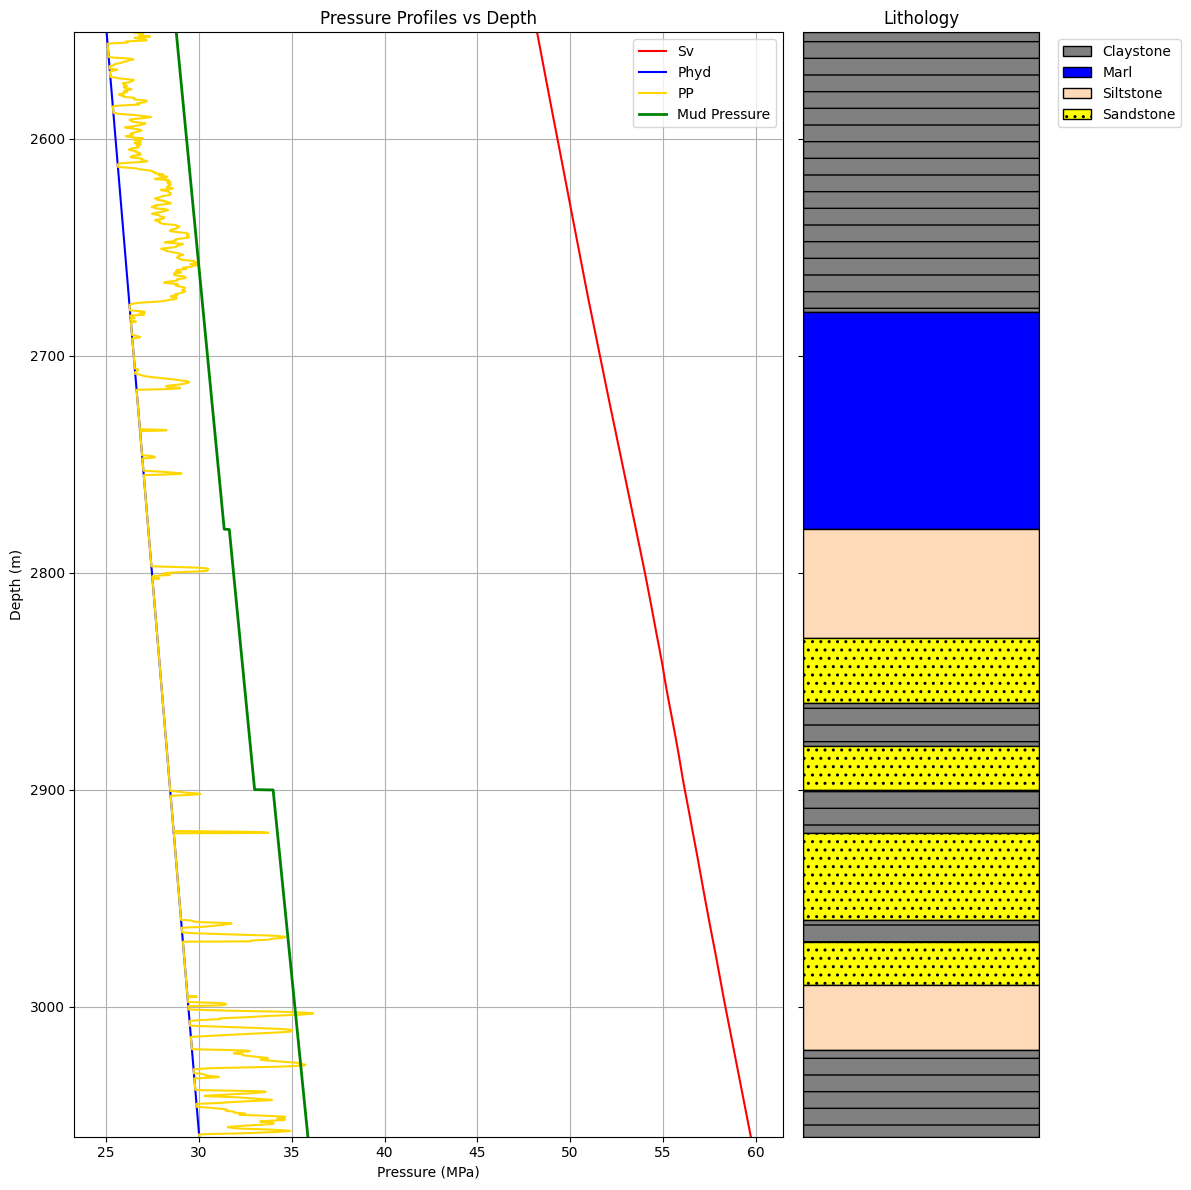

       DEPTH    MW  MudPressure
0  2551.0632  1.15    28.779819
1  2551.2132  1.15    28.781512
2  2551.3632  1.15    28.783204
3  2551.5132  1.15    28.784896
4  2551.6632  1.15    28.786588


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch

# ---------------- Create Mud Weight Profile ----------------
# Assign MW values based on depth intervals from image estimate

conditions = [
    (df['DEPTH'] >= 2551) & (df['DEPTH'] < 2780),
    (df['DEPTH'] >= 2780) & (df['DEPTH'] < 2900),
    (df['DEPTH'] >= 2900) & (df['DEPTH'] <= 3060)
]

mw_values = [1.15, 1.16, 1.195]   # kg/L

# Create MW column
df['MW'] = np.select(conditions, mw_values, default=np.nan)

# Mud pressure formula:
# P(MPa) = 0.00981 × MW × Depth
df['MudPressure'] = 0.00981 * df['MW'] * df['DEPTH']

# ---------------- Lithology Intervals ----------------
start = df['DEPTH'].min()

litho = [
    (start, 2680, 'claystone', 'grey', '-'),
    (2680, 2780, 'marl', 'blue', ''),
    (2780, 2830, 'siltstone', 'peachpuff', ''),
    (2830, 2860, 'fine sandstone', 'yellow', '..'),
    (2860, 2880, 'claystone', 'grey', '-'),
    (2880, 2900, 'fine sandstone', 'yellow', '..'),
    (2900, 2920, 'claystone', 'grey', '-'),
    (2920, 2960, 'sandstone', 'yellow', '..'),
    (2960, 2970, 'claystone', 'grey', '-'),
    (2970, 2990, 'fine sandstone', 'yellow', '..'),
    (2990, 3020, 'siltstone', 'peachpuff', ''),
    (3020, 3060, 'claystone', 'grey', '-'),

]

# ---------------- Plot ----------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 12),
    gridspec_kw={'width_ratios': [3, 1]},
    sharey=True
)

# Pressure curves
axes[0].plot(df['Sv'], df['DEPTH'], color='red', label='Sv')
axes[0].plot(df['Phyd'], df['DEPTH'], color='blue', label='Phyd')
axes[0].plot(df['PP'], df['DEPTH'], color='gold', label='PP')
axes[0].plot(df['MudPressure'], df['DEPTH'],
             color='green', linewidth=2, label='Mud Pressure')

# Depth increasing downward
axes[0].invert_yaxis()

axes[0].set_xlabel('Pressure (MPa)')
axes[0].set_ylabel('Depth (m)')
axes[0].set_title('Pressure Profiles vs Depth')
axes[0].legend()
axes[0].grid(True)

# ---------------- Lithology Track ----------------
for top, bottom, lith, color, hatch in litho:
    rect = Rectangle(
        (0, top),
        1,
        bottom - top,
        facecolor=color,
        hatch=hatch,
        edgecolor='black'
    )
    axes[1].add_patch(rect)

axes[1].invert_yaxis()

axes[1].set_xlim(0, 1)
axes[1].set_ylim(df['DEPTH'].max(), df['DEPTH'].min())

axes[1].set_xticks([])
axes[1].set_title('Lithology')

# Lithology legend
legend_patches = [
    Patch(facecolor='grey', edgecolor='black', hatch='-', label='Claystone'),
    Patch(facecolor='blue', edgecolor='black', label='Marl'),
    Patch(facecolor='peachpuff', edgecolor='black', label='Siltstone'),
    Patch(facecolor='yellow', edgecolor='black', hatch='..', label='Sandstone')
]

axes[1].legend(
    handles=legend_patches,
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

# Optional: inspect created columns
print(df[['DEPTH', 'MW', 'MudPressure']].head())

In [50]:
# Save dataframe to CSV
df.to_csv('CHANDON_2_modified.csv', index=False)

print("CSV saved successfully!")

CSV saved successfully!
